# VulnScope: what I found and what the model can do

I built VulnScope to answer a practical early-triage question: **from the title and description available for a newly published CVE, can I identify vulnerabilities that are likely to receive a High or Critical CVSS score?**

This is a severity-prioritization model, not an exploitation model. A high score means that the wording resembles historically severe CVEs; it does not mean that exploitation has occurred. I use 2020–2023 for training, early 2024 for probability calibration, late 2024 for threshold selection, and 2025 as an untouched temporal test. CVEs published in 2026 are treated as live records.

In [1]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score)

pd.set_option('display.max_columns', 30)
plt.style.use('seaborn-v0_8-whitegrid')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'processed' / 'cves_clean.parquet'
MODEL_PATH = ROOT / 'artifacts' / 'cve_priority_model.joblib'
METADATA_PATH = ROOT / 'artifacts' / 'cve_priority_model_metadata.json'
df = pd.read_parquet(DATA_PATH)
model = joblib.load(MODEL_PATH)
metadata = json.loads(METADATA_PATH.read_text())
print(f"Loaded {len(df):,} CVEs published from {int(df.publication_year.min())} to {int(df.publication_year.max())}.")

Loaded 379,693 CVEs published from 1999 to 2026.


## 1. Is the dataset usable?

The data comes from the official CVE List, but an official source can still contain missing fields, historical schema differences, and unusual timestamps. That does not make the dataset bad. It means the data needs to be interpreted in the context of how CVE reporting has changed over time.

In [2]:
quality = pd.DataFrame({
    'Check': ['Total CVEs', 'Duplicate CVE IDs', 'Missing publication dates', 'Reservation date after publication'],
    'Result': [f'{len(df):,}', f'{df.cve_id.duplicated().sum():,}', f'{df.date_published.isna().sum():,}', f'{(df.date_reserved > df.date_published).sum():,}']
})
display(quality.style.hide(axis='index'))

Check,Result
Total CVEs,"379,693"
Duplicate CVE IDs,0
Missing publication dates,2
Reservation date after publication,237


**What I take from this table:** the CVE identifier and publication-date structure is clean enough for temporal modeling. A small number of reservation dates occur after publication. Those records are real source records, but the ordering is not logically useful, so I do not use reservation duration as a model feature. I preserve the records instead of deleting them.

## 2. CVE volume and reporting completeness changed over time

A blank field does not always mean the information did not exist. For example, older CVEs often lack a vendor in the modern structured field even when a vendor is mentioned in free text. Similarly, a missing structured solution does not prove that no patch was available.

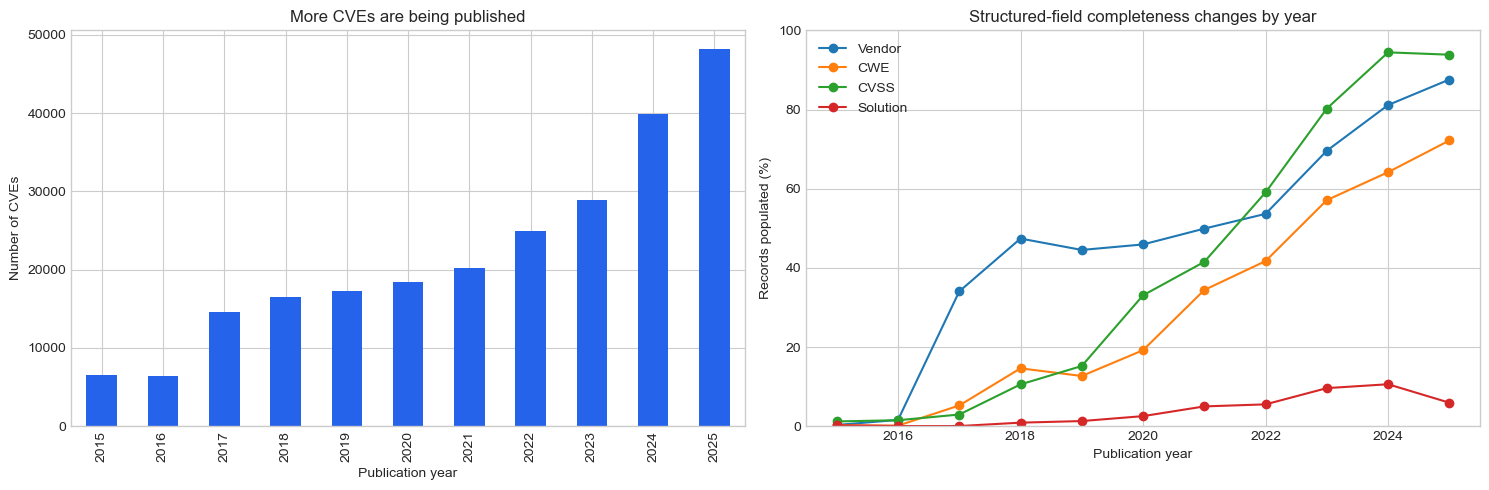

In [3]:
presence = pd.DataFrame({
    'year': df.publication_year,
    'Vendor': df.primary_vendor.notna(),
    'Product': df.products.fillna('').ne(''),
    'CWE': df.primary_cwe.notna(),
    'CVSS': df.cvss_score.notna(),
    'Solution': df.has_solution.fillna(False),
})
completeness = presence.groupby('year').mean().mul(100)
counts = df.groupby('publication_year').size()
years = range(2015, 2026)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
counts.reindex(years).plot.bar(ax=axes[0], color='#2563eb')
axes[0].set(title='More CVEs are being published', xlabel='Publication year', ylabel='Number of CVEs')
completeness.loc[2015:2025, ['Vendor', 'CWE', 'CVSS', 'Solution']].plot(ax=axes[1], marker='o')
axes[1].set(title='Structured-field completeness changes by year', xlabel='Publication year', ylabel='Records populated (%)', ylim=(0, 100))
plt.tight_layout(); plt.show()

**What stood out to me:**

- CVE volume increases substantially, especially in recent years. This may reflect more vulnerabilities, but also more CNAs, better reporting, bulk publication, and backlog processing.
- Vendor coverage looks much better in newer records. I interpret this as a schema/reporting improvement—not as evidence that older vulnerabilities had no vendors.
- Structured solutions remain relatively sparse because remediation is often published in external advisories rather than the CVE solution field.
- CWE completeness moves up and down because both reporting behavior and extraction location changed. The exact definition of “has CWE” matters.
- These shifts are also a modeling risk: a model could accidentally learn the reporting era instead of the underlying vulnerability pattern.

## 3. Additional patterns I found in the historical data

The high-level completeness chart is only the start. These views explain *why* time-aware validation matters and surface several less obvious patterns.

### The CWE result depends on what we mean by ‘has a CWE’

The earlier CSV searches the entire nested JSON record, while the cleaned Parquet uses the CNA problem-type field. The two methods answer different questions.

,CWE anywhere in JSON,CNA-structured CWE
2015,1.0,0.2
2016,1.0,0.1
2017,6.4,5.2
2018,15.4,14.6
2019,13.8,12.7
2020,20.4,19.2
2021,35.7,34.4
2022,56.5,41.7
2023,75.4,57.1
2024,86.6,64.2


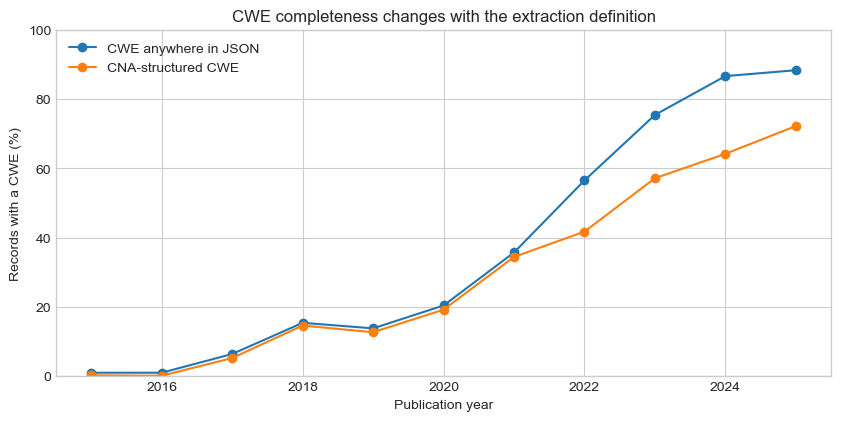

In [4]:
legacy = pd.read_csv(ROOT / 'data' / 'processed' / 'cve_completeness_by_year.csv').set_index('publication_year')
cwe_compare = pd.concat([
    legacy['has_cwe'].rename('CWE anywhere in JSON'),
    completeness['CWE'].rename('CNA-structured CWE')
], axis=1).loc[2015:2025]
display(cwe_compare.round(1))
cwe_compare.plot(figsize=(10, 4.5), marker='o', title='CWE completeness changes with the extraction definition')
plt.ylabel('Records with a CWE (%)'); plt.xlabel('Publication year'); plt.ylim(0, 100); plt.show()

**Interesting fact:** the apparent CWE trend can reverse depending on whether later enrichment containers are included. This is a useful reminder that even a simple ‘completeness’ statistic depends on a precise data definition.

### CVSS standards also changed during the study period

cvss_version,2.0,3.0,3.1,4.0
publication_year,,,,
2020.0,0.0,43.8,56.1,0.1
2021.0,0.0,19.6,80.3,0.1
2022.0,0.0,13.5,86.3,0.2
2023.0,0.0,5.0,94.8,0.2
2024.0,0.0,5.1,85.5,9.5
2025.0,0.0,2.2,70.3,27.5


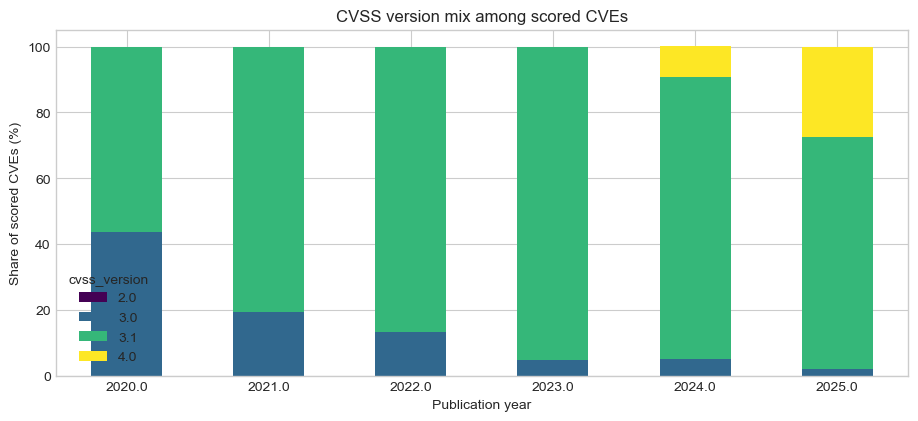

In [5]:
modern = df[df.publication_year.between(2020, 2025)].copy()
cvss_mix = pd.crosstab(modern.publication_year, modern.cvss_version, normalize='index').mul(100).round(1)
display(cvss_mix)
cvss_mix.plot.bar(stacked=True, figsize=(11, 4.5), colormap='viridis', title='CVSS version mix among scored CVEs')
plt.ylabel('Share of scored CVEs (%)'); plt.xlabel('Publication year'); plt.xticks(rotation=0); plt.show()

**Why this matters:** a model evaluated across years is also crossing scoring standards and reporting practices. This is another reason I keep CVSS fields out of the predictors and report the year split openly.

### A CVE ID year is not always its publication year

In [6]:
modern['cve_id_year'] = pd.to_numeric(modern.cve_id.str.split('-').str[1], errors='coerce')
modern['older_id_year'] = modern.cve_id_year < modern.publication_year
timing = modern.groupby('publication_year').agg(
    CVEs=('cve_id', 'size'),
    older_ID_year_pct=('older_id_year', lambda x: 100*x.mean()),
    median_reservation_to_publication_days=('days_reserved_to_published', 'median'),
    median_references=('reference_count', 'median')
).round(1)
display(timing)

,CVEs,older_ID_year_pct,median_reservation_to_publication_days,median_references
publication_year,,,,
2020.0,18363,22.2,99.7,1.0
2021.0,20177,19.5,91.8,2.0
2022.0,24998,20.8,42.0,1.0
2023.0,28847,19.0,36.0,1.0
2024.0,39924,18.2,21.0,2.0
2025.0,48153,20.4,18.0,2.0


A CVE can be reserved in one year and published later. Therefore, all training and test splits use `date_published`; splitting on the number inside the CVE ID would place some records in the wrong period.

### Different organizations produce different-looking CVE records

In [7]:
top_cnas = (modern.groupby('publication_year')['cna'].value_counts(normalize=True)
            .mul(100).rename('share_pct').reset_index()
            .groupby('publication_year').head(5))
display(top_cnas.rename(columns={'publication_year':'year', 'cna':'assigning organization', 'share_pct':'share of year (%)'}).round(1))

,year,assigning organization,share of year (%)
0,2020.0,mitre,39.3
1,2020.0,microsoft,6.9
2,2020.0,oracle,4.4
3,2020.0,redhat,3.1
4,2020.0,ibm,3.1
123,2021.0,mitre,32.1
124,2021.0,GitHub_M,5.3
125,2021.0,microsoft,4.3
126,2021.0,WPScan,3.7
127,2021.0,ibm,3.0


The leading assigning organizations change over time, and organizations differ in wording, schema usage, and scoring behavior. Vendor or CNA-specific performance can therefore differ even when overall performance looks stable.

### Outliers are investigation candidates, not automatic errors

In [8]:
outlier_cols = ['cve_id', 'publication_year', 'primary_vendor', 'product_count', 'reference_count', 'days_reserved_to_published']
print('Largest product lists')
display(df.nlargest(5, 'product_count')[outlier_cols])
print('Largest reference lists')
display(df.nlargest(5, 'reference_count')[outlier_cols])

Largest product lists


,cve_id,publication_year,primary_vendor,product_count,reference_count,days_reserved_to_published
353070,CVE-2026-5667,2026.0,Mitsubishi Electric Corporation,2480,2,72.113218
264714,CVE-2024-51984,2025.0,"Brother Industries, Ltd",743,10,232.589566
270996,CVE-2024-8105,2024.0,Acer,741,8,3.975740
264713,CVE-2024-51983,2025.0,"Brother Industries, Ltd",712,9,232.588631
264710,CVE-2024-51980,2025.0,"Brother Industries, Ltd",707,10,232.585254


Largest reference lists


,cve_id,publication_year,primary_vendor,product_count,reference_count,days_reserved_to_published
39312,CVE-2009-3555,2009.0,None,0,310,35.708333
62469,CVE-2014-0224,2014.0,None,0,305,184.875000
65407,CVE-2014-3566,2014.0,None,0,265,154.000000
74243,CVE-2015-4000,2015.0,None,0,219,6.000000
19640,CVE-2006-4339,2006.0,None,0,209,12.708333


Very large product or reference counts can describe ecosystem-wide vulnerabilities. Deleting them just because they are extreme would remove genuine security cases.

## 6. How much better is the model than simple rules?

The notebook now reads the exported CSV reports directly. These files are reproducible model evidence—not separate unexplained artifacts.

## 3. Why I used a future-year test

A random train/test split lets old and new reporting styles mix together and can make performance look unrealistically strong. Testing on 2025 answers the more realistic question: **does a model trained on the past still work on CVEs published later?** The year in the CVE ID is not used for this split; I use the actual publication timestamp.

In [9]:
columns = ['cve_id', 'publication_year', 'title', 'description', 'cvss_score']
test = df.loc[(df.publication_year == 2025) & df.cvss_score.notna(), columns].copy()
test['model_text'] = (test.title.fillna('') + ' ' + test.description.fillna('')).str.strip()
test['actual_severe'] = (test.cvss_score >= metadata['cvss_priority_cutoff']).astype(int)
test['probability'] = model.predict_proba(test.model_text)[:, 1]
test['prediction'] = (test.probability >= metadata['selected_threshold']).astype(int)
print(f"2025 test CVEs: {len(test):,}")
print(f"Actually severe: {test.actual_severe.mean():.1%}")
print(f"Decision threshold selected using 2024 data: {metadata['selected_threshold']:.3f}")

2025 test CVEs: 45,198
Actually severe: 44.0%
Decision threshold selected using 2024 data: 0.352


## 4. Main results

No single metric tells the whole story. Precision answers “when VulnScope flags something, how often is it severe?” Recall answers “of all severe CVEs, how many did it catch?” F1 balances those two. PR-AUC evaluates ranking quality across all thresholds. Brier score measures probability error, where lower is better.

In [10]:
metrics = pd.DataFrame({
    'Metric': ['Precision', 'Recall / coverage', 'F1', 'PR-AUC', 'Brier score (lower is better)'],
    'Value': [
        precision_score(test.actual_severe, test.prediction),
        recall_score(test.actual_severe, test.prediction),
        f1_score(test.actual_severe, test.prediction),
        average_precision_score(test.actual_severe, test.probability),
        brier_score_loss(test.actual_severe, test.probability),
    ]
})
display(metrics.style.hide(axis='index').format({'Value': '{:.3f}'}))

Metric,Value
Precision,0.633
Recall / coverage,0.805
F1,0.708
PR-AUC,0.764
Brier score (lower is better),0.178


**My interpretation:** the model reaches about **0.71 F1** and **0.80 recall** on a future year it was not trained on. In practical terms, it catches roughly four out of five severe CVEs, while about 63% of its alerts are truly severe. That trade-off is appropriate for prioritization: missing a severe CVE can be more costly than reviewing some extra alerts. The Brier score of about **0.18** is not an accuracy percentage; it is the average squared probability error, and lower is better.

## 5. Coverage versus efficiency

Borrowing practitioner-friendly terminology from EPSS, I call recall **coverage** and precision **efficiency**. Moving the threshold changes the balance: a lower threshold catches more severe CVEs but creates more alerts; a higher threshold reduces alert volume but misses more severe cases.

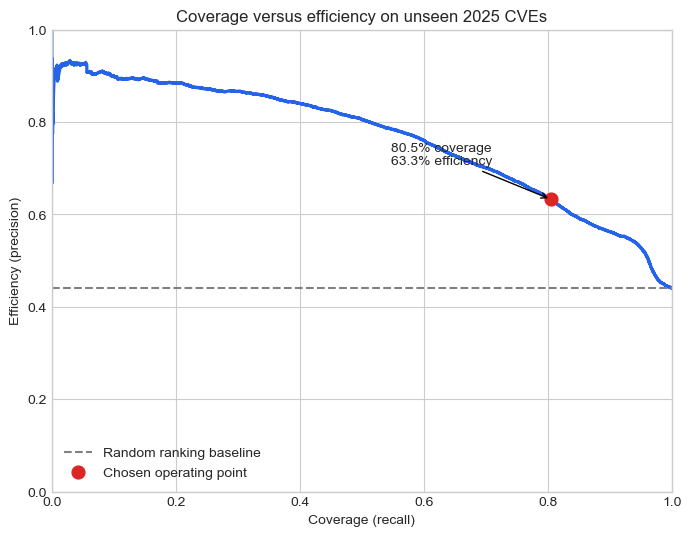

In [11]:
efficiency, coverage, thresholds = precision_recall_curve(test.actual_severe, test.probability)
selected_efficiency = precision_score(test.actual_severe, test.prediction)
selected_coverage = recall_score(test.actual_severe, test.prediction)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(coverage, efficiency, color='#2563eb', linewidth=2.3)
ax.axhline(test.actual_severe.mean(), color='gray', linestyle='--', label='Random ranking baseline')
ax.scatter(selected_coverage, selected_efficiency, color='#dc2626', s=85, zorder=3, label='Chosen operating point')
ax.annotate(f'{selected_coverage:.1%} coverage\n{selected_efficiency:.1%} efficiency', (selected_coverage, selected_efficiency), xytext=(-115, 25), textcoords='offset points', arrowprops={'arrowstyle': '->'})
ax.set(title='Coverage versus efficiency on unseen 2025 CVEs', xlabel='Coverage (recall)', ylabel='Efficiency (precision)', xlim=(0, 1), ylim=(0, 1))
ax.legend(loc='lower left'); plt.show()

**How to read this graph:** every point is a possible alert threshold. The red point is the threshold selected using 2024 validation data—not chosen after looking at 2025. There is no universally best point; the choice depends on how much analyst capacity is available and how costly missed severe CVEs are. Also, this graph is about severe CVE coverage, not exploitation coverage.

## 6. What kinds of mistakes does it make?

,Predicted below 7,Flagged as 7 or above
Actually below 7,16035,9287
Actually 7 or above,3879,15997


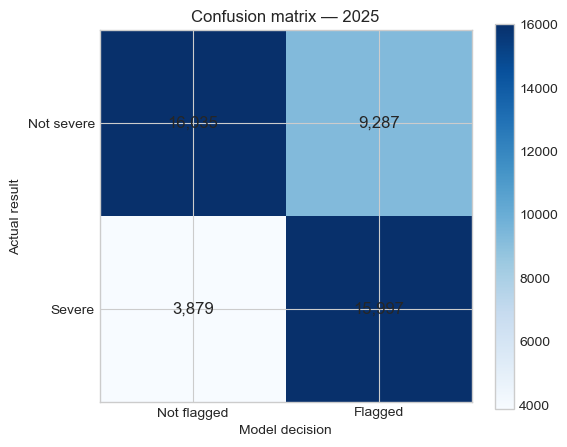

In [12]:
matrix = confusion_matrix(test.actual_severe, test.prediction)
matrix_table = pd.DataFrame(matrix, index=['Actually below 7', 'Actually 7 or above'], columns=['Predicted below 7', 'Flagged as 7 or above'])
display(matrix_table)
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix, cmap='Blues')
for (row, col), value in np.ndenumerate(matrix): ax.text(col, row, f'{value:,}', ha='center', va='center', fontsize=12)
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['Not flagged', 'Flagged'], yticklabels=['Not severe', 'Severe'], xlabel='Model decision', ylabel='Actual result', title='Confusion matrix — 2025')
plt.colorbar(image, ax=ax); plt.show()

**Why the errors matter:** false negatives are severe CVEs that the system missed, so recall is especially important. False positives are additional records an analyst would review. They are not necessarily useless alerts: a CVE just below the score-7 boundary can still deserve attention. This is why VulnScope presents evidence and probability instead of pretending the classification is certain.

## 7. Leakage and limitations

I intentionally exclude CVSS score, vector, and severity columns from the inputs. The model only receives the title and description. As an additional check, performance remains similar after removing test records whose text explicitly mentions CVSS or severity language.

The largest remaining limitation is that the official repository represents the latest state of each CVE. A description may have been edited after initial publication. Reconstructing the exact publication-time text from Git history would be the strongest next validation step. The model also does not estimate exploitation likelihood, organizational impact, or the need to patch. Those require other evidence such as asset exposure, CISA KEV, exploit intelligence, and business context.

model,precision,recall,f1,pr_auc,brier
prevalence baseline,0.000,0.000,0.000,0.440,0.246
keyword baseline,0.793,0.244,0.373,0.526,0.360
VulnScope TF-IDF SVM,0.633,0.805,0.708,0.764,0.178


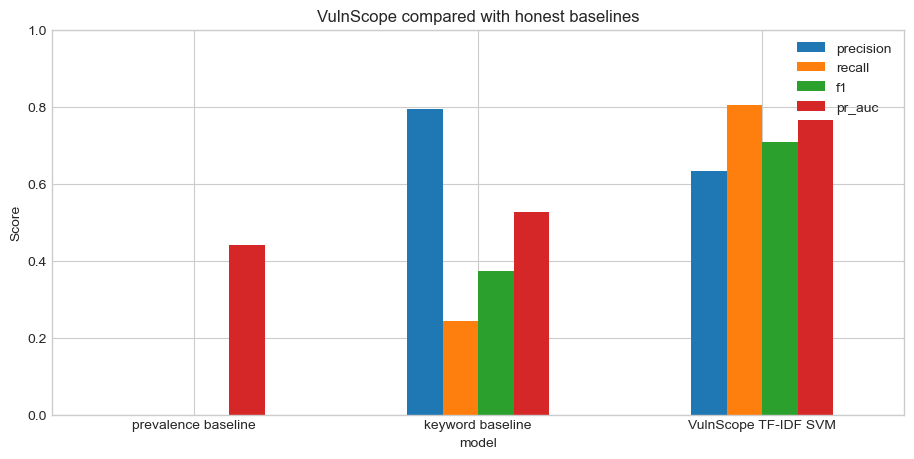

In [13]:
REPORT_DIR = ROOT / 'reports' / 'cve_priority_model'
baseline = pd.read_csv(REPORT_DIR / 'baseline_comparison.csv')
display(baseline.style.hide(axis='index').format({c:'{:.3f}' for c in ['precision','recall','f1','pr_auc','brier']}))
baseline.set_index('model')[['precision','recall','f1','pr_auc']].plot.bar(figsize=(11, 5), rot=0, title='VulnScope compared with honest baselines')
plt.ylabel('Score'); plt.ylim(0, 1); plt.show()

**What this proves:** the learned text model provides more useful ranking and classification than either predicting the majority class or relying on a short list of obvious security keywords.

### What language influences the model?

In [14]:
terms = pd.read_csv(REPORT_DIR / 'term_coefficients.csv')
display(terms.head(20))

,term,coefficient
0,code,1.790558
1,execution,1.741394
2,scripting xss unauth,1.729570
3,xss unauth,1.729570
4,unauth,1.710735
5,unauthenticated,1.595425
6,authentication,1.592386
7,escalation,1.554085
8,code execution,1.529948
9,xss unauth reflected,1.485802


These coefficients show associations learned from historical wording; they are not causal proof. They are useful for transparency because an analyst can see which phrases push a score upward or downward instead of receiving an unexplained number.

### Does performance hold across reporting groups?

In [15]:
vendor_perf = pd.read_csv(REPORT_DIR / 'performance_by_primary_vendor.csv').head(15)
cwe_perf = pd.read_csv(REPORT_DIR / 'performance_by_primary_cwe.csv').head(15)
print('Largest vendor groups')
display(vendor_perf)
print('Largest CWE groups')
display(cwe_perf)

Largest vendor groups


,primary_vendor,rows,prevalence,precision,recall,f1,pr_auc
0,MISSING,5974,0.459826,0.607971,0.916272,0.730942,0.675293
1,Linux,2721,0.700110,0.822372,0.702362,0.757644,0.858494
2,Microsoft,1254,0.736045,0.844081,0.950163,0.893986,0.953122
3,Adobe,829,0.361882,0.916107,0.910000,0.913043,0.979991
4,Apple,727,0.392022,0.502273,0.775439,0.609655,0.589033
5,IBM,606,0.217822,0.622222,0.848485,0.717949,0.831382
6,Google,577,0.606586,0.711297,0.971429,0.821256,0.891526
7,PHPGurukul,505,0.009901,0.131579,1.000000,0.232558,1.000000
8,SourceCodester,355,0.002817,0.012987,1.000000,0.025641,1.000000
9,Oracle Corporation,313,0.220447,0.773810,0.942029,0.849673,0.953134


Largest CWE groups


,primary_cwe,rows,prevalence,precision,recall,f1,pr_auc
0,MISSING,10437,0.537415,0.663753,0.839365,0.741301,0.695112
1,CWE-79,7030,0.220910,0.400424,0.121700,0.186667,0.467786
2,CWE-74,2536,0.024448,0.058663,0.693548,0.108176,0.372857
3,CWE-862,2123,0.190297,0.318976,0.678218,0.433888,0.596791
4,CWE-352,1741,0.389431,0.542289,0.160767,0.248009,0.384001
5,CWE-89,1201,0.802664,0.805369,0.995851,0.890538,0.904874
6,CWE-119,1070,0.665421,0.817185,0.627809,0.710087,0.851498
7,CWE-22,895,0.513966,0.661786,0.982609,0.790901,0.826338
8,CWE-98,575,0.979130,0.979094,0.998224,0.988566,0.992685
9,CWE-284,570,0.268421,0.617925,0.856209,0.717808,0.743716


Overall F1 can hide weak spots. These tables make subgroup variation visible and help identify where more data, better text normalization, or analyst caution is needed. Very small groups are excluded because their metrics would be unstable.

### Leakage stress test

In [16]:
leak_counts = pd.read_csv(REPORT_DIR / 'text_leakage_audit.csv')
leak_sensitivity = pd.read_csv(REPORT_DIR / 'leakage_sensitivity.csv')
display(leak_counts)
print('Performance after excluding explicit CVSS/severity wording')
display(leak_sensitivity.style.hide(axis='index').format('{:.3f}'))

,indicator,rows,share
0,explicit_cvss_score,9,0.000199
1,severity_word,3353,0.074185
2,cvss_vector,334,0.007390


Performance after excluding explicit CVSS/severity wording


rows,prevalence,precision,recall,f1,pr_auc,brier
41577.000,0.456,0.633,0.811,0.711,0.767,0.182


Performance does not collapse when explicit score/vector/severity wording is removed from the test set. That supports the claim that the model learned broader vulnerability-language patterns, although reconstructing exact publication-time text is still the strongest next audit.

### Looking at real mistakes

In [17]:
fp = pd.read_csv(REPORT_DIR / 'false_positives_top100.csv')
fn = pd.read_csv(REPORT_DIR / 'false_negatives_top100.csv')
error_show = ['cve_id','primary_vendor','primary_cwe','cvss_score','priority_probability','title']
print('Highest-confidence false positives')
display(fp[error_show].head(8))
print('Most confidently missed severe CVEs')
display(fn[error_show].head(8))

Highest-confidence false positives


,cve_id,primary_vendor,primary_cwe,cvss_score,priority_probability,title
0,CVE-2025-44176,NaN,NaN,6.5,0.995206,NaN
1,CVE-2024-58255,Huawei,CWE-200,5.0,0.991659,NaN
2,CVE-2024-58256,Huawei,CWE-200,4.5,0.991659,NaN
3,CVE-2024-58257,Huawei,CWE-200,5.7,0.991659,NaN
4,CVE-2025-8652,Kenwood,CWE-78,6.8,0.989381,Kenwood DMX958XR JKWifiService Command Injecti...
5,CVE-2025-8649,Kenwood,CWE-78,6.8,0.989381,Kenwood DMX958XR JKWifiService Command Injecti...
6,CVE-2025-8651,Kenwood,CWE-78,6.8,0.989381,Kenwood DMX958XR JKWifiService Command Injecti...
7,CVE-2025-26507,"HP, Inc.",CWE-121,6.3,0.988023,"Certain HP LaserJet Pro, HP LaserJet Enterpris..."


Most confidently missed severe CVEs


,cve_id,primary_vendor,primary_cwe,cvss_score,priority_probability,title
0,CVE-2025-25166,gabrieldarezzo,CWE-352,7.1,0.020650,WordPress InLocation plugin <= 1.8 - Cross Sit...
1,CVE-2025-23660,waltercerrudo,CWE-352,7.1,0.021659,WordPress MFPlugin plugin <= 1.3 - CSRF to Cro...
2,CVE-2025-23978,Ninos,CWE-352,7.1,0.023067,WordPress FlashCounter plugin <= 1.1.8 - CSRF ...
3,CVE-2025-23513,jd7777,CWE-352,7.1,0.023747,WordPress Bible Embed plugin <= 0.0.4 - CSRF t...
4,CVE-2025-24562,Optimal Access,CWE-352,7.1,0.024274,WordPress KBucket plugin <= 4.1.6 - CSRF to St...
5,CVE-2025-24561,awcode,CWE-352,7.1,0.024581,WordPress ReviewsTap plugin <= 1.1.2 - CSRF to...
6,CVE-2025-36895,Google,NaN,7.5,0.027984,NaN
7,CVE-2025-23662,ryscript,CWE-352,7.1,0.029914,WordPress WP Panoramio plugin <= 1.5.0 - CSRF ...


Error review is more actionable than chasing one headline metric. False positives show which phrases can overstate severity; false negatives reveal severe cases described with less alarming language. Both become candidates for future feature engineering.

## 9. How the research becomes a live product

In [18]:
live_path = ROOT / 'data' / 'predictions' / 'cve_priority_live_2026.parquet'
live = pd.read_parquet(live_path)
live_summary = pd.DataFrame({
    'Measure': ['2026 CVEs scored', 'Currently flagged', 'Flagged share', 'Latest source revision'],
    'Value': [f'{len(live):,}', f"{live['flagged'].sum():,}", f"{live['flagged'].mean():.1%}", str(live['source_revision'].dropna().iloc[-1])[:12]]
})
display(live_summary.style.hide(axis='index'))

Measure,Value
2026 CVEs scored,"70,812"
Currently flagged,"50,588"
Flagged share,71.4%
Latest source revision,c1031e0b2861


The historical work is not only a static analysis. A daily pipeline checks the official CVE repository, processes changed records, scores changed 2026 CVEs, and writes the live Parquet used by the Streamlit interface. The LLM explains retrieved evidence but never invents the model probability.

## 8. Final conclusion

The dataset is suitable for this scoped project because identifiers and publication dates are reliable, missingness is measured rather than hidden, and evaluation respects time. The results suggest that public CVE text contains a useful early severity signal that generalizes into 2025.

VulnScope should be used as a **prioritization assistant**: it ranks new CVEs, retrieves similar historical examples, and explains the evidence behind a score. It should not replace CVSS, threat intelligence, or analyst judgment.